<a href="https://colab.research.google.com/github/qositok565/Praktikum_AI_1/blob/main/Regresi_Linear_Berganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Persiapan Alat & Data**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

* **pandas**: Mengubah data mentah (dictionary) menjadi tabel digital bernama DataFrame.
* **train_test_split**: Alat untuk membagi data menjadi dua bagian: satu untuk belajar, satu untuk ujian.
* **LinearRegression**: Otak AI yang akan menghitung hubungan antar variabel.
* **metrics & numpy**: Alat ukur untuk melihat seberapa besar kesalahan (error) prediksi AI.
* **matplotlib.pyplot**: Untuk menggambar grafik agar data bisa "berbicara" secara visual.

In [12]:
data_rumah = {
    'Luas_Tanah': [50, 60, 80, 100, 120, 150],
    'Jml_Kamar': [1, 2, 2, 3, 3, 4],
    'Harga_Juta': [300, 400, 550, 700, 850, 1100]
}

df_rumah = pd.DataFrame(data_rumah)
print(df_rumah)

   Luas_Tanah  Jml_Kamar  Harga_Juta
0          50          1         300
1          60          2         400
2          80          2         550
3         100          3         700
4         120          3         850
5         150          4        1100


* Kita mendefinisikan kolom-kolom yang saling berhubungan. Di sini, Luas Tanah dan Jumlah Kamar adalah **Fitur**, sedangkan Harga adalah **Target**.

**2. Memisahkan Variabel (X dan y)**

In [13]:
X = df_rumah[['Luas_Tanah', 'Jml_Kamar']]
y = df_rumah['Harga_Juta']

* **X (Independent Variables)**: Faktor penyebab. Menggunakan kurung siku ganda [[ ]] karena dalam regresi berganda, X harus berbentuk tabel (2D).
* **y (Dependent Variable)**: Hasil yang ingin diprediksi.

**3. Proses "Belajar" (Training)**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

* **test_size=0.2**: Kita mengambil 20% data untuk simulasi ujian nanti.
* **X_train & y_train**: Data yang dipelajari AI.
* **X_test & y_test**: Soal ujian yang jawabannya sudah kita pegang tapi disembunyikan dari AI.

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

* **model.fit**: Di sinilah keajaiban terjadi. AI mencoba mencari rumus terbaik. Karena ada dua fitur, rumusnya menjadi:

$$Harga = a + (b_1 \times Luas) + (b_2 \times Kamar)$$

**4. Melihat Hasil Pemikiran AI**

In [16]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2):", model.coef_)
# b1 → pengaruh luas tanah
# b2 → pengaruh jumlah kamar

Intercept (a): -83.33333333333337
Koefisien (b1, b2): [7.77777778 2.77777778]


* **Intercept (a)**: Titik berangkat harga.
* **Koefisien (b1)**: Berapa juta harga naik tiap $1m^2$ luas tanah bertambah.
* **Koefisien (b2)**: Berapa juta harga naik tiap ada penambahan 1 kamar.

**5. Uji Coba & Evaluasi**

In [17]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Harga_Juta Asli:", y_test.values)

Prediksi: [308.33333333 388.88888889]
Harga_Juta Asli: [300 400]


* AI mencoba menjawab soal ujian (**X_test**) dan hasilnya disimpan di **y_pred**.

In [18]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 9.722222222222229
MSE: 96.4506172839508
RMSE: 9.820927516479836


* **MAE (Mean Absolute Error)**: Rata-rata selisih harga prediksi dengan harga asli dalam satuan Juta.
* **RMSE**: Memberikan penalti lebih besar jika ada prediksi yang melesetnya terlalu jauh.

**6. Prediksi Masa Depan**

In [19]:
data_rumah_baru = [[180, 5]]
prediksi = model.predict(data_rumah_baru)

print("Prediksi harga rumah untuk luas 180m2 dan 5 kamar:", prediksi[0])

Prediksi harga rumah untuk luas 180m2 dan 5 kamar: 1330.5555555555557


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


* Kita mencoba memasukkan data rumah yang tidak ada di tabel awal (Luas 180, 5 Kamar). AI akan menghitung harganya menggunakan rumus yang sudah ia temukan saat latihan tadi.

**7. Visualisasi Perbandingan**

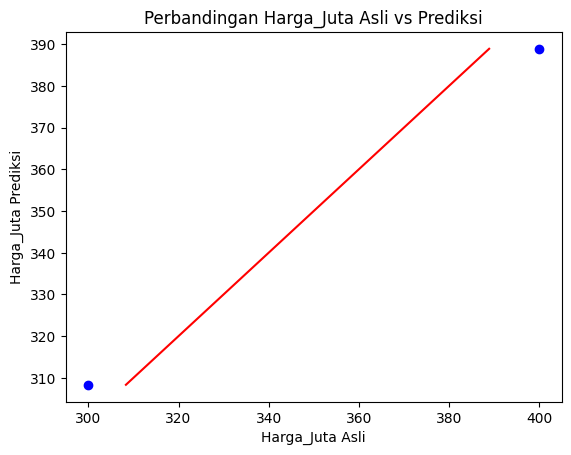

In [20]:
plt.scatter(y_test, y_pred, color='blue', label='Data Asli')
plt.plot(y_pred, model.predict(X_test), color='red', label='Prediksi')
plt.xlabel("Harga_Juta Asli")
plt.ylabel("Harga_Juta Prediksi")
plt.title("Perbandingan Harga_Juta Asli vs Prediksi")
plt.show()

* **Scatter**: Titik-titik hasil tebakan vs kenyataan.
* **Plot**: Garis lurus yang menunjukkan tren prediksi. Jika titik biru menempel pada garis merah, berarti AI kamu sangat akurat.

**Analisis Akhir**

**1. Akurasi**: Dengan hanya 6 data, AI ini sangat rentan terhadap kesalahan jika ada "data aneh" (misal: tanah kecil tapi sangat mahal karena di pusat kota). Namun, untuk data yang linier seperti ini, hasilnya akan tampak sangat akurat.

**2. Skalabilitas**: Kamu bisa menambah fitur lain seperti "Jumlah Lantai" atau "Garasi" ke dalam variabel X dengan cara yang sama.

**3. Kesimpulan**: Model ini menunjukkan bahwa Luas Tanah dan Jumlah Kamar memiliki korelasi positif yang kuat terhadap harga. Setiap penambahan aset (luas/kamar) akan menaikkan harga rumah secara konsisten secara linear.